# Geneformer: base vs continual training

Paired bootstrap comparison on **batch mixing score** and **kNN label F1**:
- **V1:** `geneformer_V1-10M-i2048` vs `continue_geneformer_V1-10M-i2048_continue`
- **V2:** `geneformer_V2-104M-i4096` vs `continue_geneformer_V2-104M-i4096_continue`

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.multitest import multipletests

%run fig2_plot_utils.py

RESULTS_PATH = os.path.expanduser(
    "~/scFM_eval/results/embedding_bootstrap/embedding.metrics.bootstrap.csv"
)
OUTPUT_DIR = "./fig3_metrics"

MODEL_PAIRS = [
    {
        "id": "v1",
        "title": "Geneformer V1",
        "base": "geneformer_V1-10M-i2048",
        "continue": "continue_geneformer_V1-10M-i2048_continue",
        "base_label": "GF-V1",
        "continue_label": "GF-V1 [continue]",
    },
    {
        "id": "v2",
        "title": "Geneformer V2",
        "base": "geneformer_V2-104M-i4096",
        "continue": "continue_geneformer_V2-104M-i4096_continue",
        "base_label": "GF-V2",
        "continue_label": "GF-V2 [continue]",
    },
]

PLOT_METRICS = ["batch_ASW", "kNN_label_f1_macro"]

METRIC_LABELS = {
    "batch_ASW": "Batch mixing score",
    "kNN_label_f1_macro": "kNN label F1",
}

results = pd.read_csv(RESULTS_PATH)
all_models = {m for pair in MODEL_PAIRS for m in (pair["base"], pair["continue"])}
pair_df = results[results["model"].isin(all_models)].copy()
print(f"Rows: {len(pair_df)}")
print(pair_df.groupby("model").size())


Rows: 40
model
continue_geneformer_V1-10M-i2048_continue     10
continue_geneformer_V2-104M-i4096_continue    10
geneformer_V1-10M-i2048                       10
geneformer_V2-104M-i4096                      10
dtype: int64


In [2]:
def fmt_p(p):
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def paired_metric_values(df, metric, base_model, continue_model):
    base = df[df["model"] == base_model].set_index("run")[metric].sort_index()
    cont = df[df["model"] == continue_model].set_index("run")[metric].sort_index()
    runs = base.index.intersection(cont.index)
    return base.loc[runs], cont.loc[runs], runs


def paired_stats_table(df, pair, metrics):
    rows = []
    for metric in metrics:
        base_vals, cont_vals, runs = paired_metric_values(
            df, metric, pair["base"], pair["continue"]
        )
        diff = cont_vals - base_vals
        _, wilcoxon_p = stats.wilcoxon(cont_vals, base_vals)
        _, t_p = stats.ttest_rel(cont_vals, base_vals)
        rows.append(
            {
                "comparison": pair["id"],
                "comparison_title": pair["title"],
                "base_model": pair["base"],
                "continue_model": pair["continue"],
                "metric": metric,
                "metric_label": METRIC_LABELS.get(metric, metric),
                "n_pairs": len(runs),
                "base_mean": base_vals.mean(),
                "continue_mean": cont_vals.mean(),
                "mean_diff_continue_minus_base": diff.mean(),
                "diff_ci95_low": np.percentile(diff, 2.5),
                "diff_ci95_high": np.percentile(diff, 97.5),
                "wilcoxon_p": wilcoxon_p,
                "paired_t_p": t_p,
            }
        )

    out = pd.DataFrame(rows)
    out["wilcoxon_p_holm"] = multipletests(out["wilcoxon_p"], method="holm")[1]
    return out


def plot_paired_slopes(df, metrics, pair, save_path=None):
    apply_publication_style()

    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(3.2 * n_metrics, 4.5), sharey=False)
    if n_metrics == 1:
        axes = [axes]

    x_base, x_cont = 0, 1
    base_color = "#4C78A8"
    cont_color = "#F58518"

    for ax, metric in zip(axes, metrics):
        base_vals, cont_vals, _ = paired_metric_values(
            df, metric, pair["base"], pair["continue"]
        )

        for b, c in zip(base_vals, cont_vals):
            ax.plot([x_base, x_cont], [b, c], color="#B0B7C3", linewidth=0.9, alpha=0.7, zorder=1)

        ax.scatter(
            [x_base] * len(base_vals), base_vals,
            color=base_color, s=28, zorder=2, label=pair["base_label"],
        )
        ax.scatter(
            [x_cont] * len(cont_vals), cont_vals,
            color=cont_color, s=28, zorder=2, label=pair["continue_label"],
        )
        ax.scatter([x_base], [base_vals.mean()], color=base_color, s=70, marker="D", zorder=3)
        ax.scatter([x_cont], [cont_vals.mean()], color=cont_color, s=70, marker="D", zorder=3)

        ax.set_xticks([x_base, x_cont])
        ax.set_xticklabels([pair["base_label"], pair["continue_label"]], rotation=25, ha="right")
        ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=10)
        ax.set_xlim(-0.35, 1.35)
        ax.grid(axis="y", color="#E5E5E5", linewidth=0.6)
        ax.set_axisbelow(True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[:2], labels[:2], loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{pair['title']}: paired bootstrap comparison", fontsize=11, y=1.08)
    fig.tight_layout()

    if save_path:
        save_publication_figure(fig, save_path)

    return fig, axes


def format_stats_summary(stats_df):
    cols = [
        "comparison_title",
        "metric_label",
        "base_mean",
        "continue_mean",
        "mean_diff_continue_minus_base",
        "diff_ci95_low",
        "diff_ci95_high",
        "wilcoxon_p",
        "wilcoxon_p_holm",
    ]
    out = stats_df[cols].copy()
    out = out.rename(
        columns={
            "comparison_title": "Comparison",
            "metric_label": "Metric",
            "base_mean": "Base mean",
            "continue_mean": "Continue mean",
            "mean_diff_continue_minus_base": "Δ (continue - base)",
            "diff_ci95_low": "Δ CI low",
            "diff_ci95_high": "Δ CI high",
            "wilcoxon_p": "Wilcoxon p",
            "wilcoxon_p_holm": "Holm p",
        }
    )
    for col in ["Base mean", "Continue mean", "Δ (continue - base)", "Δ CI low", "Δ CI high"]:
        out[col] = out[col].map(lambda x: f"{x:.3f}")
    for col in ["Wilcoxon p", "Holm p"]:
        out[col] = out[col].map(fmt_p)
    return out


def interpret_comparison(pair_stats, pair):
    lines = [f"### {pair['title']}", ""]
    lines.append(
        f"Comparing **{pair['base_label']}** vs **{pair['continue_label']}** "
        f"on {int(pair_stats['n_pairs'].iloc[0])} paired bootstrap runs."
    )
    lines.append("")

    for _, row in pair_stats.iterrows():
        diff = row["mean_diff_continue_minus_base"]
        direction = "increased" if diff > 0 else "decreased"
        sig = row["wilcoxon_p_holm"] < 0.05
        ci = f"[{row['diff_ci95_low']:.3f}, {row['diff_ci95_high']:.3f}]"

        if sig:
            verdict = f"Continual training **significantly {direction}** {row['metric_label'].lower()}"
        else:
            verdict = f"No significant change in {row['metric_label'].lower()}"

        lines.append(
            f"- **{row['metric_label']}:** {verdict} "
            f"(Δ = {diff:+.3f}, 95% CI {ci}, Holm {fmt_p(row['wilcoxon_p_holm'])})."
        )

    batch = pair_stats[pair_stats["metric"] == "batch_ASW"].iloc[0]
    f1 = pair_stats[pair_stats["metric"] == "kNN_label_f1_macro"].iloc[0]

    lines.append("")
    if batch["wilcoxon_p_holm"] < 0.05 and f1["wilcoxon_p_holm"] < 0.05:
        if batch["mean_diff_continue_minus_base"] > 0 and f1["mean_diff_continue_minus_base"] > 0:
            summary = "Continual training improves both batch mixing and kNN label F1."
        elif batch["mean_diff_continue_minus_base"] < 0 and f1["mean_diff_continue_minus_base"] > 0:
            summary = "Continual training improves kNN label F1 but reduces batch mixing."
        elif batch["mean_diff_continue_minus_base"] > 0 and f1["mean_diff_continue_minus_base"] < 0:
            summary = "Continual training improves batch mixing but reduces kNN label F1."
        else:
            summary = "Continual training reduces both batch mixing and kNN label F1."
    elif batch["wilcoxon_p_holm"] < 0.05:
        summary = "Only batch mixing shows a significant change after continual training."
    elif f1["wilcoxon_p_holm"] < 0.05:
        summary = "Only kNN label F1 shows a significant change after continual training."
    else:
        summary = "Neither metric shows a significant change after continual training."

    lines.append(f"**Summary:** {summary}")
    return "\n".join(lines)


In [3]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

stats_tables = []
for pair in MODEL_PAIRS:
    sub_df = pair_df[pair_df["model"].isin([pair["base"], pair["continue"]])]
    stats_tables.append(paired_stats_table(sub_df, pair, PLOT_METRICS))

stats_df = pd.concat(stats_tables, ignore_index=True)
stats_path = os.path.join(OUTPUT_DIR, "gf_continue_paired_stats.csv")
stats_df.to_csv(stats_path, index=False)

display(Markdown("## Statistical results"))
display(format_stats_summary(stats_df))

display(Markdown("## Interpretation"))
for pair in MODEL_PAIRS:
    pair_stats = stats_df[stats_df["comparison"] == pair["id"]]
    display(Markdown(interpret_comparison(pair_stats, pair)))


## Statistical results

,Comparison,Metric,Base mean,Continue mean,Δ (continue - base),Δ CI low,Δ CI high,Wilcoxon p,Holm p
0,Geneformer V1,Batch mixing score,0.841,0.835,-0.006,-0.009,-0.002,p = 0.002,p = 0.004
1,Geneformer V1,kNN label F1,0.868,0.899,0.031,-0.035,0.096,p = 0.160,p = 0.160
2,Geneformer V2,Batch mixing score,0.810,0.834,0.024,0.020,0.028,p = 0.002,p = 0.004
3,Geneformer V2,kNN label F1,0.933,0.952,0.019,0.003,0.048,p = 0.002,p = 0.004


## Interpretation

### Geneformer V1

Comparing **GF-V1** vs **GF-V1 [continue]** on 10 paired bootstrap runs.

- **Batch mixing score:** Continual training **significantly decreased** batch mixing score (Δ = -0.006, 95% CI [-0.009, -0.002], Holm p = 0.004).
- **kNN label F1:** No significant change in knn label f1 (Δ = +0.031, 95% CI [-0.035, 0.096], Holm p = 0.160).

**Summary:** Only batch mixing shows a significant change after continual training.

### Geneformer V2

Comparing **GF-V2** vs **GF-V2 [continue]** on 10 paired bootstrap runs.

- **Batch mixing score:** Continual training **significantly increased** batch mixing score (Δ = +0.024, 95% CI [0.020, 0.028], Holm p = 0.004).
- **kNN label F1:** Continual training **significantly increased** knn label f1 (Δ = +0.019, 95% CI [0.003, 0.048], Holm p = 0.004).

**Summary:** Continual training improves both batch mixing and kNN label F1.

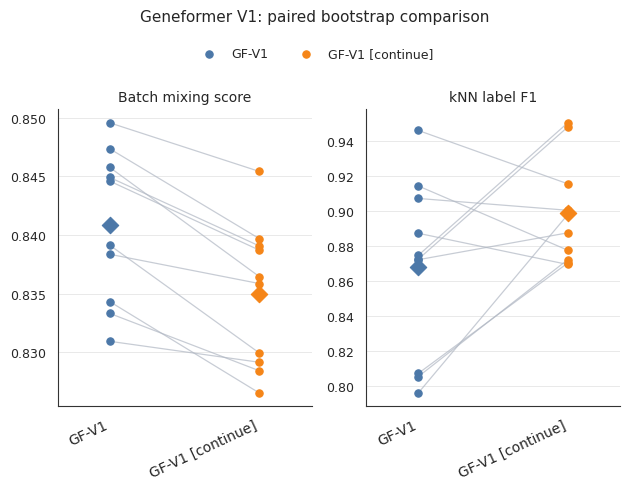

Saved plot to ./fig3_metrics/gf_v1_continue_paired_slope.png


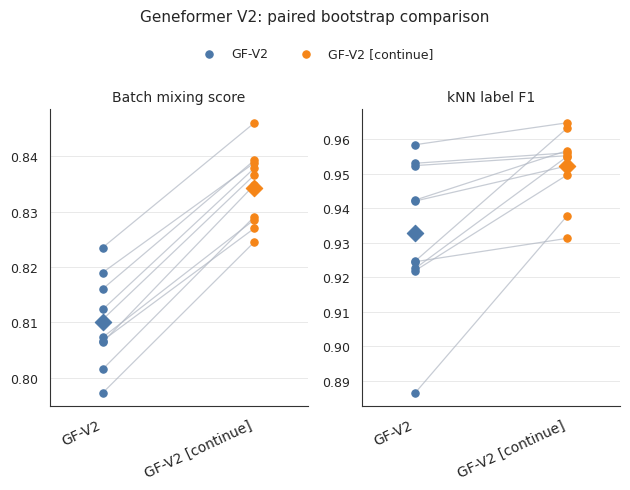

Saved plot to ./fig3_metrics/gf_v2_continue_paired_slope.png
Saved stats to ./fig3_metrics/gf_continue_paired_stats.csv


In [4]:
for pair in MODEL_PAIRS:
    sub_df = pair_df[pair_df["model"].isin([pair["base"], pair["continue"]])]
    plot_path = os.path.join(OUTPUT_DIR, f"gf_{pair['id']}_continue_paired_slope.png")

    fig, axes = plot_paired_slopes(
        sub_df,
        PLOT_METRICS,
        pair,
        save_path=plot_path,
    )
    plt.show()
    plt.close(fig)
    print(f"Saved plot to {plot_path}")

print(f"Saved stats to {stats_path}")
